# Homework 2  Solutions
**Notebook:** Detailed solutions to HW2 problems with circuit implementations and measurements

## Structure

| Section | Content |
|---------|---------|
| **HW2 Problem 1** | Separable vs entangled state identification |
| **HW2 Problem 2** | 2-qubit state preparation via Schmidt/SVD decomposition |
| **HW2 Problem 4** | Measuring gate â€” sequential vs joint measurement proof |

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

import numpy as np
import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from math import pi
from numpy import pi as npi

# --- IBM Quantum hardware setup (optional) ---
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(channel='ibm_quantum', token=os.environ.get('IBM_QUANTUM_TOKEN'))

### Homework 2


<b> Problem 1 : Separable and entangled states</b> 

Determine which of the following states are entangled. If the state is not entangled, show how to write that as a tensor product; if it is entangled, prove it. 

 (a) $\frac{2}{3} |00\rangle + \frac{1}{3} |01\rangle  - \frac{2}{3} |11\rangle $ 
  
 (b) $\frac{1}{2} \left( |00\rangle - i  |01\rangle  + i  |10\rangle + |11\rangle  \right)$ 
 
 (c)  $\frac{1}{2} \left( |00\rangle -   |01\rangle  +  |10\rangle +  |11\rangle  \right)$ 
  
  
 <b> Solution </b>
 The separable two-qubit state is  given by 
 
$ (\alpha_1 |0\rangle + \beta_1 |1\rangle ) (\alpha_2 |0\rangle + \beta_2 |1\rangle )
  =  \alpha_1\alpha_2 |00\rangle + \beta_1\beta_2 |11\rangle + \alpha_1 \beta_2|01\rangle + \alpha_2 \beta_1|10\rangle $

The general two-qubit state is  given by 
$ a_0 |00\rangle + a_3 |11\rangle + a_1|01\rangle + a_2|10\rangle $

So that the separable state satisfies 
 $a_0/a_1 = a_2/a3$. 
 From this criterion only the state (b) is entangled
 which is given as the tensor product $(|0\rangle + i |1\rangle )
 (|0\rangle - i |1\rangle ))$. 

<b> Problem 2: Preparation of the general 2-Qubit pure state </b>

 Using Schmidt decomposition and its relation to the Singular value decomposition of matrices, suggest the algorithm to prepare general 2-Qubit pure state
  \begin{align}  \tag{1}
 |\psi\rangle = a_{00} |00\rangle + a_{01} |01\rangle  +  a_{10} |10\rangle  +  a_{11} |11\rangle  \end{align}
 
 Apply this procedure to prepare the example 2-Qbit state
  
 (a)  $| \Phi^{\pm} \rangle = \frac{1}{\sqrt{2}} ( | 00 \rangle \pm | 11 \rangle )$  
 
 (b)  $| \Psi^{\pm} \rangle = \frac{1}{\sqrt{2}} ( | 01 \rangle \pm | 10 \rangle ) $
 
 (c) $ \Phi \rangle = \frac{1}{\sqrt{12}} (3 |00\rangle + |01\rangle + |10\rangle  - |11\rangle)$

 The states $| \Phi^{\pm} \rangle $ and $| \Psi^{\pm} \rangle $ 
 are called Bell states, they are used in quantum cryptography  algorithms. 
  Write code in Qiskit, give the link to the Jupyter notebook. 
  
  <b> Solution </b>
  
   First, let us considet the general aproach to the 2-Qubit state preparation. 
   
   Consider the circuit $V_1 U_2cX_{12} B_1 $.    Let's prove that the above circuit prepares the state 
 \begin{align}  \tag{2}
 |\psi\rangle = a_{00}|00\rangle +   a_{10}|10\rangle + a_{01}|01\rangle +  a_{11}|11\rangle \end{align}    
   where
    $A= \left( \begin{smallmatrix}  a_{00} & a_{10} \\ a_{01}  & a_{11}  \end{smallmatrix} \right) = U B V^T$            
 where  unitary matrices $U$, $V$ and diagonal $B$ present the singular value decomposition of the matrix A. 
  If the matrix coefficients are $V= \left( \begin{smallmatrix}  v_{11} & v_{12} \\ v_{21}  & v_{22} \end{smallmatrix} \right)$, $U= \left( \begin{smallmatrix} u_{11} & u_{12} \\ u_{21}  & u_{22} \end{smallmatrix} \right)$, $B= \left( \begin{smallmatrix} b_{1} & 0 \\ 0 & b_{2} \end{smallmatrix} \right)$
so that
  
\begin{align}  \tag{2}
& a_{00} = v_{11} u_{11} b_1 + v_{12} u_{12} b_2 \\ & a_{10} = u_{11} v_{21} b_1 + v_{22} u_{12} b_2 \\ &  a_{01} = v_{11} u_{21} b_1 + v_{12} u_{22} b_2 \\ &  a_{11} = v_{21} u_{21} b_1 + v_{22} v_{22} b_2 \end{align}
 

 The action of the above circuit on the state $|00\rangle$ can be calculated  as (here upper and lower Qubits in the circuit correspond to subscript indices $0$ and $1$, respectively )
 
 $ |\psi\rangle    =  V_0 U_1  C_{01} B_0 |00\rangle=  V_0 U_1   
 C_{01}  (b_1|0\rangle + b_2|1\rangle)_0 |0\rangle_1= V_0 U_1 (b_1|00\rangle + b_2|11\rangle)= 
 b_1 ( v_{11} |0\rangle + v_{21} |1\rangle)_0 ( u_{11} |0\rangle + u_{21} |1\rangle)_1  + b_2 ( v_{12} |0\rangle + v_{22} |1\rangle)_0  ( u_{12} |0\rangle + u_{22} |1\rangle)_1= (b_1 u_{11}v_{11} + b_2 u_{12}v_{12} )|00\rangle + 
 (b_1v_{11} u_{21} + b_2 v_{12}u_{22}) |01\rangle + (b_1v_{21} u_{11} + b_2 v_{22}u_{12}) |10\rangle +
  (b_1u_{21} v_{21} + b_2 u_{22}v_{22}) |11\rangle $
  
Comparing this equation with the general form \eqref{Eq:psi} we see that the coefficients  are indeed coincide with that of the matrix $A$
\eqref{Eq:acoeff}.  
    
  In general the two-Qubit state \eqref{Eq:Gen2Qubit} 
  as $\psi = V_0 U_1  C_{01} B_0$ where  $A= \left( \begin{smallmatrix}  a_{00} & a_{10} \\ a_{01}  & a_{11} \end{smallmatrix} \right) = U B V^T$.  
             
From this general rule we get 

(a) $\Phi^+ =  C_{01}H_0 |00\rangle$,  

(b) $\Psi^+ =  X_0 C_{01} H_0 |00\rangle $, 

(c) $\Phi =   U3_1 (\theta)Z_1U3_0 (\theta) C_{01} U3_0 (\theta_B)  |00\rangle$, 

where $\theta =2arccos( 0.9732)   $, $\theta_B  =2 arccos(0.9342)  $.   

Let us check the state (c) using qiskit. 


In [2]:
from numpy import array
from scipy.linalg import svd

# SVD-based 2-qubit state preparation for state (c):
# |Phi> = (1/sqrt(12)) * (3|00> + |01> + |10> - |11>)
# The coefficient matrix A is defined such that |psi> = sum_{ij} A_{ij} |ij>
# with A laid out as: A = [[a_00, a_10], [a_01, a_11]]
A = array([[3/np.sqrt(12), 1/np.sqrt(12)], [1/np.sqrt(12), -1/np.sqrt(12)]])

# SVD: A = U B VT  where U, VT are unitary and B is diagonal (singular values)
# U implements the single-qubit unitary on qubit 1 (target)
# VT implements the single-qubit unitary on qubit 0 (control)
# B gives the Schmidt coefficients; its action on |0> is equivalent to U3(thetaB)|0>
U, B, VT = svd(A)
print("U=", U, "\n")   # Unitary for qubit 1 (target) â€” will be approximated as U3(theta)*Z
print("B=", B, "\n")   # Singular values (Schmidt coefficients) â€” applied as U3(thetaB) on qubit 0
print("VT=", VT, "\n") # Unitary for qubit 0 (control) â€” will be approximated as U3(theta)

U= [[-0.97324899 -0.22975292]
 [-0.22975292  0.97324899]] 

B= [0.93417236 0.35682209] 

VT= [[-0.97324899 -0.22975292]
 [ 0.22975292 -0.97324899]] 



In [3]:
from numpy import array
from scipy.linalg import svd
# define a matrix
A = array([[3/np.sqrt(12), 1/np.sqrt(12)], [1/np.sqrt(12), -1/np.sqrt(12)]])
#print(A);
# SVD
U, B, VT = svd(A);
print("U=", U, "\n")

print("B=",B ,"\n")

print("VT=", VT, "\n")


U= [[-0.97324899 -0.22975292]
 [-0.22975292  0.97324899]] 

B= [0.93417236 0.35682209] 

VT= [[-0.97324899 -0.22975292]
 [ 0.22975292 -0.97324899]] 



Matrices $U$ and $V$ are unitary, they can be presented as $U_3(\theta)Z$ and $U_3(\theta)$. Matrix $B$ is non-unitary, but its action on the state $|0\rangle$ is the same as of the gate $U_3(\theta_B)$.

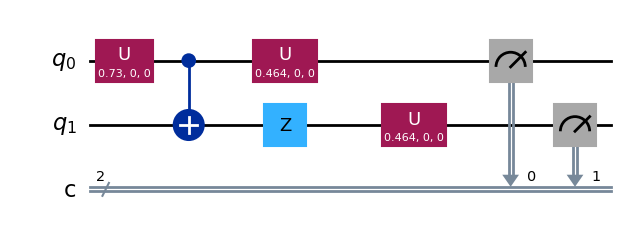

In [5]:
from numpy.ma import arccos


circuit1 = QuantumCircuit(2, 2)
# SVD-based circuit: |Phi> = V_0 U_1 CX_{01} B_0 |00>
# Following the decomposition A = U B VT:
#   Step 1: Apply B on qubit 0 â€” U3(thetaB) rotates |0> to (b1|0> + b2|1>)
#           This creates the Schmidt superposition on qubit 0 (control)
thetaB = 2*arccos(0.9342)
circuit1.u(thetaB, 0, 0, 0)   # u3 â†’ u in Qiskit 1.x; thetaB = 2*arccos(0.9342) from B matrix

#   Step 2: CNOT (CX) entangles qubits: maps (b1|0>+b2|1>)|0> â†’ b1|00> + b2|11>
#           This creates the Schmidt decomposition structure
circuit1.cx(0, 1)

#   Step 3: Apply Z on qubit 1 to account for the sign difference in U vs V factors
circuit1.z(1)

#   Step 4: Apply U_1 = U3(theta) on qubit 1 (target) â€” rotates using left singular vectors
thetaU = 2*arccos(0.9732)
circuit1.u(thetaU, 0, 0, 1)    # theta = 2*arccos(0.9732) from U matrix

#   Step 5: Apply V_0 = U3(theta) on qubit 0 (control) â€” rotates using right singular vectors
circuit1.u(thetaU, 0, 0, 0)    # same theta because U ≈ VT for this symmetric state

circuit1.measure(range(2), range(2))
circuit1.draw(output='mpl')

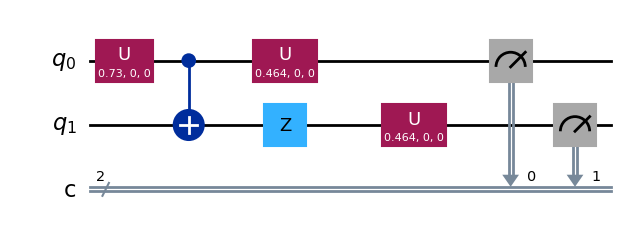

In [8]:
circuit1 = QuantumCircuit(2, 2)
circuit1.u(thetaB, 0, 0, 0)    # u3 â†’ u in Qiskit 1.x
circuit1.cx(0, 1)
circuit1.z(1)
circuit1.u(thetaU, 0, 0, 0)
circuit1.u(thetaU, 0, 0, 1)
circuit1.measure(range(2), range(2))
circuit1.draw(output='mpl')

Let's check that the above circuit yield the state (c). 

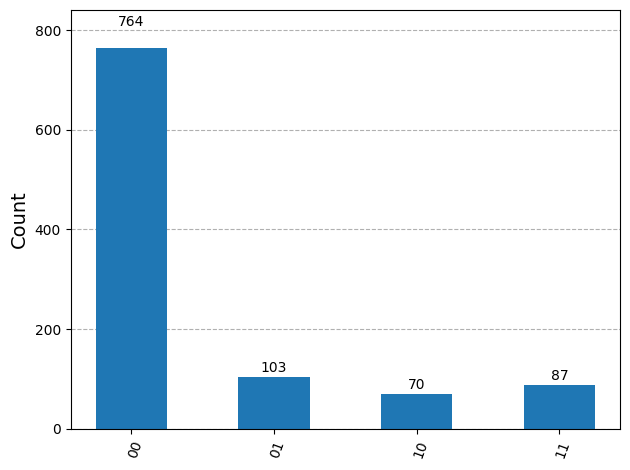

In [9]:
backend = AerSimulator()
resultZSim = backend.run(transpile(circuit1, backend), shots=1024).result()
plot_histogram([resultZSim.get_counts(circuit1)])

<b> Problem 4 : Measuring gate </b>

Let us consider the general state of $n$ Qbits $|\Psi\rangle_n$ which can be written in the form 
 \begin{equation} \label{Eq:P6} \tag{2}
  |\Psi\rangle_{n} = \sum_x \alpha_x |x\rangle_m 
  |\Phi_x\rangle_{n-m}
 \end{equation}
 %
According to the Born rule if we measure $m<n$ Qbits then with probability $|\alpha_x|^2$ the result will be $|x\rangle$ and after this measurement 
the $n$ Qbits will be in the sate 
 \begin{equation} \nonumber
   |x\rangle_m |\Phi_x\rangle_{n-m}
 \end{equation}

(a) Suppose that first $m$ Qbits are measured and immediately after additional $k$  Qbits are measured,  so that $m+k\leq n$. Find the possible states after 
these two measurements and their associated probabilities by applying first $m$ measurements and then $k$ measurements. 

(b) Show that the result obtained in (a) coincides with that of the single measurement of $m+k$ Qbits. 

Hint: use the relation between joint $p(xy)$ and conditional $p(y|x)$ probabilities 
for two outcomes $x$ and $y$:
   \begin{equation} \label{Eq:P6-1} \tag{3}
   p(xy)= p(y|x)p(x)
 \end{equation}   
   
   
   <b> Solution </b> 
   The state \eqref{Eq:P6} in general can be written as 
   \begin{align}
  |\Psi\rangle_{n} = \sum_{x,y,z} \alpha_{xyz} |x\rangle_m 
  |y\rangle_{k} |z\rangle_{n-m-k}  =
   \sum_x \alpha_x |x\rangle_m 
  \sum_{y,z}\frac{\alpha_{xyz}}{\alpha_x}
  |  y\rangle_{k}  |z\rangle_{n-m-k} 
   \end{align}
   where $\alpha_x= \sqrt{\sum_{y,z} |\alpha_{xyz}|^2} $.
  The first measurement yields
  state $|x\rangle_m 
  (\sum_{y,z} \frac{\alpha_{xyz}}{\alpha_x} 
  |  y\rangle_{k}  |z\rangle_{n-m-k}  $   
  with probability $p(x) = |\alpha_x|^2 / \sum_{x} 
  |\alpha_{x}|^2$. 
 The subsequent measurement yields the state   
 $|x\rangle_m (\sum_{z} \frac{\alpha_{xyz}}{\alpha_{xy}} 
  |  y\rangle_{k}  |z\rangle_{n-m-k}  $
 with probability $ p (y|x) = |\alpha_{xy}|^2 /\sqrt{\sum_{y,x} |\alpha_{xy}|^2} $ where $\alpha_{xy} = \sqrt{\sum_z|\alpha_{xyz}|^2}$.
 The single measurement of $k+m$ qubits yields this state with probability 
 $p(xy)= \sum_z |\alpha_{xyz}|^2/\sum_{x,y,z} 
  |\alpha_{xyz}|^2 $. 
  Since $
  |\alpha_{x}|^2= \sum_{y,z} 
  |\alpha_{xyz}|^2$
 It's easy to see that the above probabilities satisfy Eq.\eqref{Eq:P6-1}. 
